# Volume over time: reference vs. cascade

Cell volume of each MOF over time, comparing the reference MOF-OFF model (a fairchem UMA fine-tune), a stock MACE-MP small run, and the latest cascade run (MACE-MP small retrained on MOF-OFF labels).
The reference is drawn in gray and MACE-MP small in orange. The cascade run is drawn in blue, with dotted lines labeling the model version of each accepted chunk wherever it changes.
All runs use `init_config_mof_crystalline_1000K.json` (MTK NPT, 1000 K, 1 GPa, dt = 1 fs).

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, StrMethodFormatter, NullFormatter
from sqlalchemy import create_engine, text

DB_URL = os.environ.get('CASCADE_DB_URL', 'postgresql://ase:pw@globus1:5432/cascade')
engine = create_engine(DB_URL)

REFERENCE_RUN = 'reference-2026.08.21-19:31:10-43722e'
MACE_SMALL_RUN = 'reference-2026.09.22-18:51:28-bc5828'  # run_reference_dynamics.py --calc-type mace --calc-model small
CASCADE_RUN = '2026.09.03-22:03:35-e79143'
MOF_NAMES = ['MOF5', 'qmofb0f0d29', 'qmofb52c6c5']  # traj_id order in the init config
DT_FS = 1.0
EQUIL_PS = 5.0
REF_LABEL = 'reference (MOF-OFF)'
SMALL_LABEL = 'MACE-MP small'
CASCADE_LABEL = 'cascade: MACE-MP small'  # distributions below use frames from this time onward

In [2]:
_LATTICE = re.compile(r'Lattice="([^"]+)"')

def _volume(header: str) -> float:
    cell = np.array(_LATTICE.search(header).group(1).split(), dtype=float).reshape(3, 3)
    return abs(np.linalg.det(cell))


def load_volumes(run_id: str) -> pd.DataFrame:
    """Volume per frame from each trajectory's accepted chunks, in the same order as TrajectoryDB.get_trajectory_atoms

    Parses only the extxyz Lattice header, so full Atoms objects are never built.
    """
    query = text("""
        select f.traj_id, f.chunk_id, f.frame_index, k.model_version,
               convert_from(substring(f.atoms_blob from 1 for 400), 'UTF8') as header
        from trajectory_frames f
        join trajectory_chunks k
          on k.run_id = f.run_id and k.traj_id = f.traj_id
         and k.chunk_id = f.chunk_id and k.attempt_index = f.attempt_index
        where f.run_id = :run_id and k.audit_status = 'PASSED'
        order by f.traj_id, f.chunk_id, f.frame_index
    """)
    with engine.connect() as conn:
        df = pd.read_sql(query, conn, params={'run_id': run_id})
    # The first frame of each chunk after chunk 0 repeats the previous chunk's last frame
    # (frame_index is offset by the trajectory's global step, so drop by position within the chunk)
    first_in_chunk = df.groupby(['traj_id', 'chunk_id']).cumcount() == 0
    df = df[(df.chunk_id == 0) | ~first_in_chunk].copy()
    df['volume'] = df.pop('header').map(_volume)
    df['step'] = df.groupby('traj_id').cumcount()
    df['time_ps'] = df.step * DT_FS / 1000
    return df


ref = load_volumes(REFERENCE_RUN)
small = load_volumes(MACE_SMALL_RUN)
cas = load_volumes(CASCADE_RUN)
for run_id, df in [(REFERENCE_RUN, ref), (MACE_SMALL_RUN, small), (CASCADE_RUN, cas)]:
    print(run_id, df.groupby('traj_id').step.max().to_dict())

reference-2026.08.21-19:31:10-43722e {0: 10000, 1: 10000, 2: 10000}
reference-2026.09.22-18:51:28-bc5828 {0: 10000, 1: 10000, 2: 10000}
2026.09.03-22:03:35-e79143 {0: 10000, 1: 10000, 2: 10000}


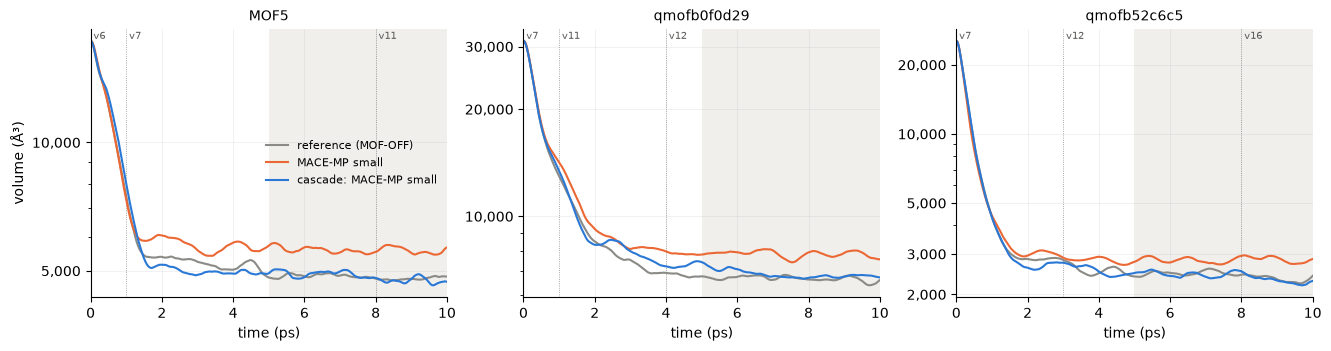

In [3]:
REF_COLOR = '#8a8a86'
SMALL_COLOR = '#eb6834'
CASCADE_COLOR = '#2a78d6'

fig, axes = plt.subplots(1, len(MOF_NAMES), figsize=(4.4 * len(MOF_NAMES), 3.4), layout='constrained')
for traj_id, (ax, mof) in enumerate(zip(axes, MOF_NAMES)):
    r = ref.query('traj_id == @traj_id')
    c = cas.query('traj_id == @traj_id')
    ax.plot(r.time_ps, r.volume, color=REF_COLOR, lw=1.5, label=REF_LABEL)
    s = small.query('traj_id == @traj_id')
    ax.plot(s.time_ps, s.volume, color=SMALL_COLOR, lw=1.5, label=SMALL_LABEL)
    ax.plot(c.time_ps, c.volume, color=CASCADE_COLOR, lw=1.5, label=CASCADE_LABEL)
    # Mark where the model version changes
    changed = c[c.model_version.diff() != 0]  # includes the first frame, labeling the starting version
    for t, v in zip(changed.time_ps, changed.model_version):
        if t > 0:
            ax.axvline(t, color=REF_COLOR, lw=0.6, ls=':', zorder=0)
        ax.annotate(f'v{v}', (t, 1), xycoords=('data', 'axes fraction'), xytext=(2, -2),
                    textcoords='offset points', ha='left', va='top', fontsize=7, color='#555553')
    ax.axvspan(EQUIL_PS, c.time_ps.max(), color='#f0efec', zorder=-1, lw=0)
    ax.set_xlim(0, c.time_ps.max())
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(LogLocator(subs=(1, 2, 3, 5)))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_title(mof, fontsize=10)
    ax.set_xlabel('time (ps)')
    ax.grid(alpha=0.25, lw=0.5)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel('volume (Å³)')
axes[0].legend(frameon=False, fontsize=8, loc='center right')
#fig.suptitle(f'Cell volume (cascade run {CASCADE_RUN}); shaded: t ≥ {EQUIL_PS:g} ps')
plt.show()

## Volume distributions after equilibration

Frames from t ≥ `EQUIL_PS` for each MOF. Consecutive frames are strongly correlated, so the spread of each histogram is meaningful but the frame count overstates the effective sample size.

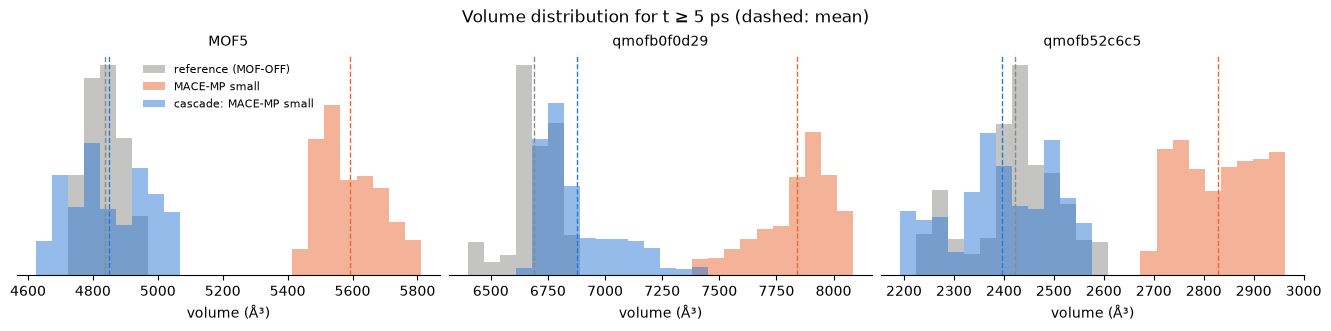

In [4]:
late = pd.concat([
    ref.assign(source=REF_LABEL),
    small.assign(source=SMALL_LABEL),
    cas.assign(source=CASCADE_LABEL),
]).query('time_ps >= @EQUIL_PS')
late['mof'] = late.traj_id.map(dict(enumerate(MOF_NAMES)))

fig, axes = plt.subplots(1, len(MOF_NAMES), figsize=(4.4 * len(MOF_NAMES), 3.2), layout='constrained')
for ax, mof in zip(axes, MOF_NAMES):
    g = late.query('mof == @mof')
    bins = np.linspace(g.volume.min(), g.volume.max(), 25)
    for source, color in [(REF_LABEL, REF_COLOR), (SMALL_LABEL, SMALL_COLOR), (CASCADE_LABEL, CASCADE_COLOR)]:
        v = g.query('source == @source').volume
        if v.empty:
            continue
        ax.hist(v, bins=bins, density=True, histtype='stepfilled', alpha=0.5, color=color, label=source)
        ax.axvline(v.mean(), color=color, lw=1, ls='--')
    ax.set_title(mof, fontsize=10)
    ax.set_xlabel('volume (Å³)')
    ax.set_yticks([])
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
#axes[0].set_ylabel('density')
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f'Volume distribution for t ≥ {EQUIL_PS:g} ps (dashed: mean)')
plt.show()

In [5]:
SOURCES = [REF_LABEL, SMALL_LABEL, CASCADE_LABEL]
stats = (late.groupby(['mof', 'source']).volume.agg(['mean', 'std', 'count']).unstack('source')
         .reindex(columns=pd.MultiIndex.from_product([['mean', 'std', 'count'], SOURCES])))
ref_mean = stats[('mean', REF_LABEL)]
columns = {}
for source in SOURCES:
    columns[(source, 'mean (Å³)')] = stats[('mean', source)].round(0)
    columns[(source, 'std (Å³)')] = stats[('std', source)].round(1)
    if source != REF_LABEL:
        columns[(source, 'Δ mean vs ref (%)')] = (100 * (stats[('mean', source)] / ref_mean - 1)).round(2)
        columns[(source, 'std / ref std')] = (stats[('std', source)] / stats[('std', REF_LABEL)]).round(2)
    columns[(source, 'n frames')] = stats[('count', source)].fillna(0).astype(int)
summary = pd.DataFrame(columns).loc[MOF_NAMES]
summary.columns = pd.MultiIndex.from_tuples(summary.columns)
summary

reference (MOF-OFF)                   MACE-MP small           \
                      mean (Å³) std (Å³) n frames     mean (Å³) std (Å³)   
mof                                                                        
MOF5                     4836.0     53.7     5001        5593.0     93.6   
qmofb0f0d29              6691.0    102.6     5001        7840.0    160.5   
qmofb52c6c5              2421.0     89.0     5001        2829.0     77.6   

                                                     cascade: MACE-MP small  \
            Δ mean vs ref (%) std / ref std n frames              mean (Å³)   
mof                                                                           
MOF5                    15.66          1.74     5001                 4850.0   
qmofb0f0d29             17.17          1.56     5001                 6878.0   
qmofb52c6c5             16.83          0.87     5001                 2397.0   

                                                               
            std (Å³) Δ mean vs ref (%) std / ref std n frames  
mof                                                            
MOF5           116.9              0.28          2.18     5001  
qmofb0f0d29    170.2              2.79          1.66     5001  
qmofb52c6c5    101.4             -1.01          1.14     5001